In [1]:
# Cell 1 — Connect to DuckDB and explore tables
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = duckdb.connect('../data/ecommerce.duckdb')

# Check all table sizes
tables = ['orders', 'order_items', 'payments', 'reviews', 
          'customers', 'products', 'sellers']

for t in tables:
    count = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:20s}: {count:>10,} rows")

orders              :     99,441 rows
order_items         :    112,650 rows
payments            :    103,886 rows
reviews             :     99,224 rows
customers           :     99,441 rows
products            :     32,951 rows
sellers             :      3,095 rows


In [2]:
# Cell 2 — Understand the orders table
orders = conn.execute("SELECT * FROM orders LIMIT 5").df()
print("Orders columns:", orders.columns.tolist())
print("\nOrder status distribution:")
print(conn.execute("""
    SELECT order_status, COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct
    FROM orders
    GROUP BY order_status
    ORDER BY count DESC
""").df().to_string())

Orders columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Order status distribution:
  order_status  count    pct
0    delivered  96478  97.02
1      shipped   1107   1.11
2     canceled    625   0.63
3  unavailable    609   0.61
4     invoiced    314   0.32
5   processing    301   0.30
6      created      5   0.01
7     approved      2   0.00


In [3]:
# Cell 3 — Revenue Analysis
# This is your first real JOIN — orders + order_items + payments
revenue = conn.execute("""
    SELECT 
        DATE_TRUNC('month', CAST(o.order_purchase_timestamp AS TIMESTAMP)) AS month,
        COUNT(DISTINCT o.order_id)        AS total_orders,
        COUNT(DISTINCT o.customer_id)     AS unique_customers,
        ROUND(SUM(oi.price), 2)           AS product_revenue,
        ROUND(SUM(oi.freight_value), 2)   AS freight_revenue,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue,
        ROUND(AVG(oi.price), 2)           AS avg_order_value
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY DATE_TRUNC('month', CAST(o.order_purchase_timestamp AS TIMESTAMP))
    ORDER BY month
""").df()

print(revenue.to_string())

        month  total_orders  unique_customers  product_revenue  freight_revenue  total_revenue  avg_order_value
0  2016-09-01             1                 1           134.97             8.49         143.46            44.99
1  2016-10-01           265               265         40325.11          6165.55       46490.66           128.83
2  2016-12-01             1                 1            10.90             8.72          19.62            10.90
3  2017-01-01           750               750        111798.36         15684.01      127482.37           122.45
4  2017-02-01          1653              1653        234223.40         37015.92      271239.32           126.06
5  2017-03-01          2546              2546        359198.85         55132.10      414330.95           123.99
6  2017-04-01          2303              2303        340669.68         50142.72      390812.40           132.61
7  2017-05-01          3546              3546        489338.25         77513.15      566851.40          

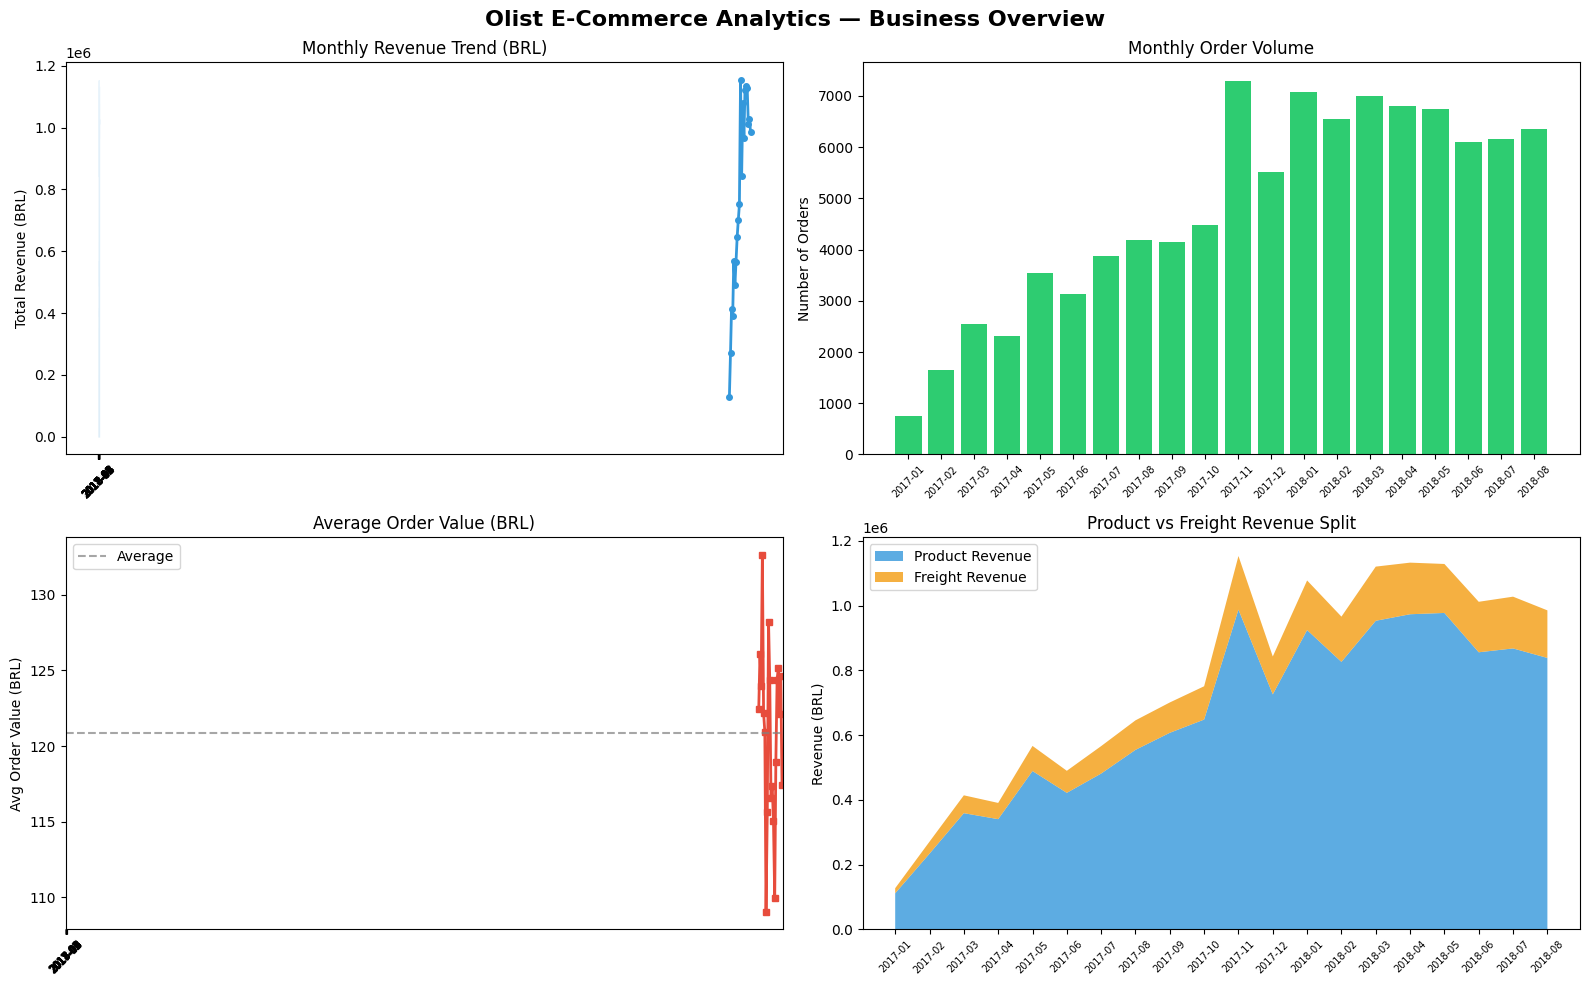

Saved!


In [4]:
# Cell 4 — Revenue Trend Chart
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Olist E-Commerce Analytics — Business Overview', 
             fontsize=16, fontweight='bold')

# Filter out incomplete months
revenue_clean = revenue[revenue['month'] >= '2017-01-01']

# 1. Monthly Revenue Trend
axes[0,0].plot(revenue_clean['month'], revenue_clean['total_revenue'], 
               color='#3498db', linewidth=2, marker='o', markersize=4)
axes[0,0].fill_between(range(len(revenue_clean)), revenue_clean['total_revenue'], 
                        alpha=0.1, color='#3498db')
axes[0,0].set_title('Monthly Revenue Trend (BRL)')
axes[0,0].set_ylabel('Total Revenue (BRL)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_xticks(range(len(revenue_clean)))
axes[0,0].set_xticklabels([str(m)[:7] for m in revenue_clean['month']], rotation=45, fontsize=7)

# 2. Monthly Orders
axes[0,1].bar(range(len(revenue_clean)), revenue_clean['total_orders'], color='#2ecc71')
axes[0,1].set_title('Monthly Order Volume')
axes[0,1].set_ylabel('Number of Orders')
axes[0,1].set_xticks(range(len(revenue_clean)))
axes[0,1].set_xticklabels([str(m)[:7] for m in revenue_clean['month']], rotation=45, fontsize=7)

# 3. Average Order Value
axes[1,0].plot(revenue_clean['month'], revenue_clean['avg_order_value'],
               color='#e74c3c', linewidth=2, marker='s', markersize=4)
axes[1,0].set_title('Average Order Value (BRL)')
axes[1,0].set_ylabel('Avg Order Value (BRL)')
axes[1,0].set_xticks(range(len(revenue_clean)))
axes[1,0].set_xticklabels([str(m)[:7] for m in revenue_clean['month']], rotation=45, fontsize=7)
axes[1,0].axhline(y=revenue_clean['avg_order_value'].mean(), 
                   color='gray', linestyle='--', alpha=0.7, label='Average')
axes[1,0].legend()

# 4. Revenue split: Product vs Freight
axes[1,1].stackplot(range(len(revenue_clean)),
                    revenue_clean['product_revenue'],
                    revenue_clean['freight_revenue'],
                    labels=['Product Revenue', 'Freight Revenue'],
                    colors=['#3498db', '#f39c12'], alpha=0.8)
axes[1,1].set_title('Product vs Freight Revenue Split')
axes[1,1].set_ylabel('Revenue (BRL)')
axes[1,1].legend(loc='upper left')
axes[1,1].set_xticks(range(len(revenue_clean)))
axes[1,1].set_xticklabels([str(m)[:7] for m in revenue_clean['month']], rotation=45, fontsize=7)

plt.tight_layout()
plt.savefig('../data/revenue_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

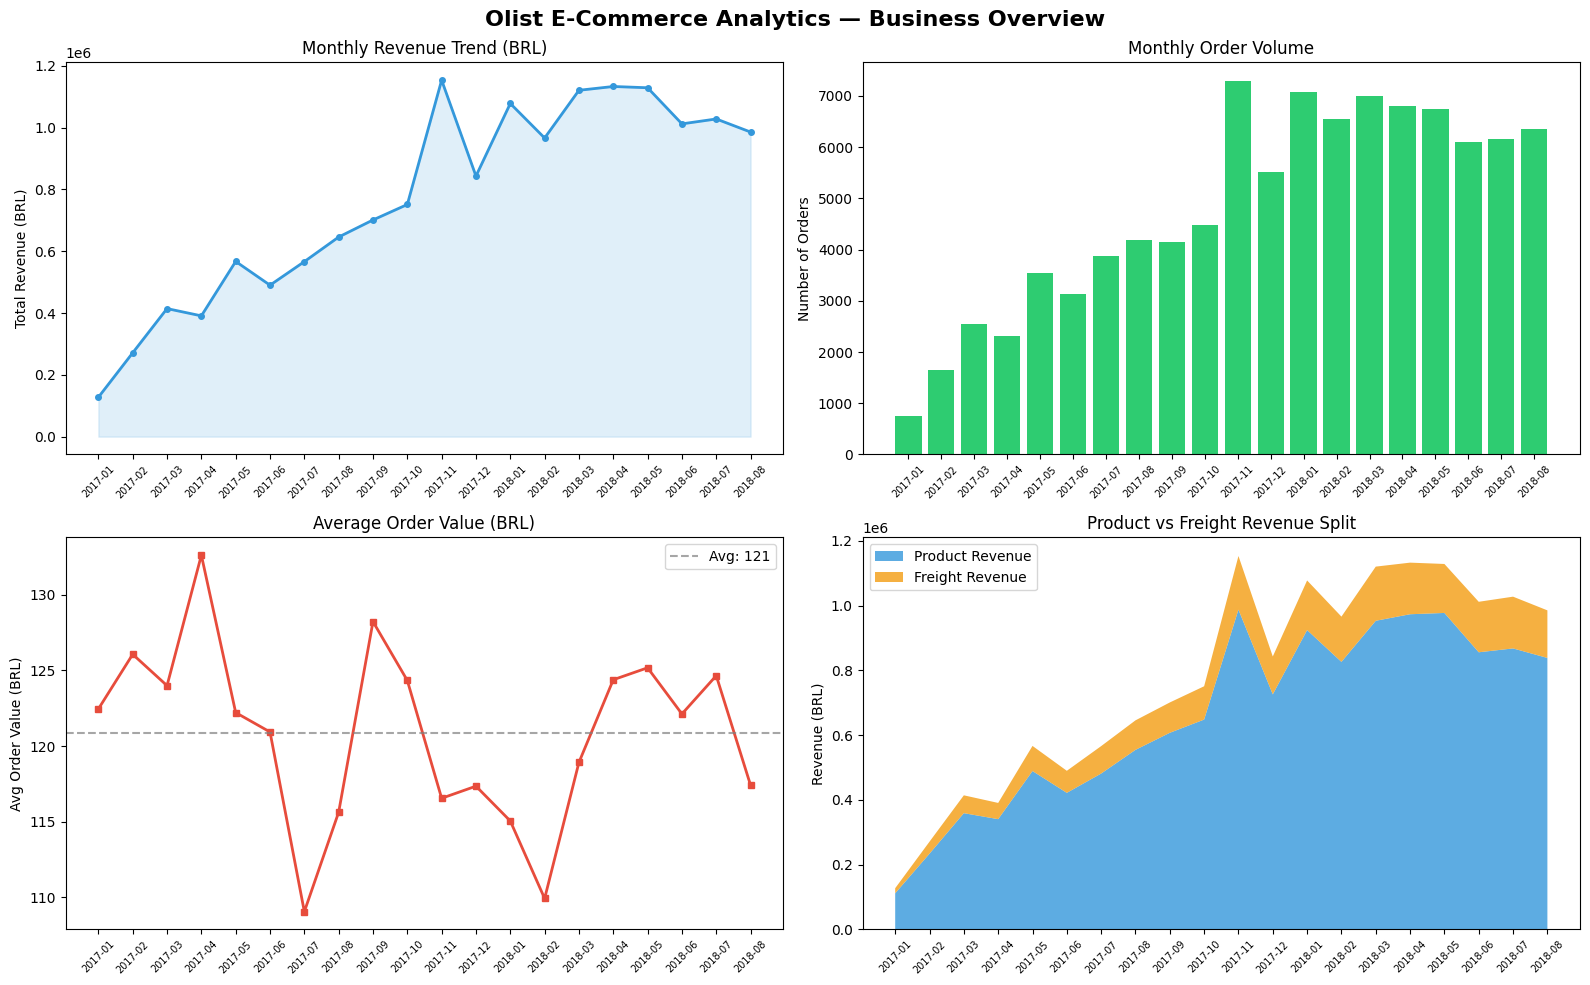

Saved!


In [5]:
# Cell 5 — Fixed Revenue Charts
revenue_clean = revenue[revenue['month'] >= '2017-01-01'].copy()
revenue_clean['month'] = pd.to_datetime(revenue_clean['month'])
revenue_clean = revenue_clean.reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Olist E-Commerce Analytics — Business Overview', 
             fontsize=16, fontweight='bold')

# 1. Monthly Revenue Trend
axes[0,0].plot(revenue_clean.index, revenue_clean['total_revenue'], 
               color='#3498db', linewidth=2, marker='o', markersize=4)
axes[0,0].fill_between(revenue_clean.index, revenue_clean['total_revenue'], 
                        alpha=0.15, color='#3498db')
axes[0,0].set_title('Monthly Revenue Trend (BRL)')
axes[0,0].set_ylabel('Total Revenue (BRL)')
axes[0,0].set_xticks(revenue_clean.index)
axes[0,0].set_xticklabels(revenue_clean['month'].dt.strftime('%Y-%m'), rotation=45, fontsize=7)

# 2. Monthly Orders
axes[0,1].bar(revenue_clean.index, revenue_clean['total_orders'], color='#2ecc71')
axes[0,1].set_title('Monthly Order Volume')
axes[0,1].set_ylabel('Number of Orders')
axes[0,1].set_xticks(revenue_clean.index)
axes[0,1].set_xticklabels(revenue_clean['month'].dt.strftime('%Y-%m'), rotation=45, fontsize=7)

# 3. Average Order Value
axes[1,0].plot(revenue_clean.index, revenue_clean['avg_order_value'],
               color='#e74c3c', linewidth=2, marker='s', markersize=4)
axes[1,0].set_title('Average Order Value (BRL)')
axes[1,0].set_ylabel('Avg Order Value (BRL)')
axes[1,0].set_xticks(revenue_clean.index)
axes[1,0].set_xticklabels(revenue_clean['month'].dt.strftime('%Y-%m'), rotation=45, fontsize=7)
axes[1,0].axhline(y=revenue_clean['avg_order_value'].mean(), 
                   color='gray', linestyle='--', alpha=0.7, label=f"Avg: {revenue_clean['avg_order_value'].mean():.0f}")
axes[1,0].legend()

# 4. Revenue split
axes[1,1].stackplot(revenue_clean.index,
                    revenue_clean['product_revenue'],
                    revenue_clean['freight_revenue'],
                    labels=['Product Revenue', 'Freight Revenue'],
                    colors=['#3498db', '#f39c12'], alpha=0.8)
axes[1,1].set_title('Product vs Freight Revenue Split')
axes[1,1].set_ylabel('Revenue (BRL)')
axes[1,1].legend(loc='upper left')
axes[1,1].set_xticks(revenue_clean.index)
axes[1,1].set_xticklabels(revenue_clean['month'].dt.strftime('%Y-%m'), rotation=45, fontsize=7)

plt.tight_layout()
plt.savefig('../data/revenue_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [8]:
# Cell 6 Fixed — Top Product Categories by Revenue
categories = conn.execute("""
    WITH category_revenue AS (
        SELECT 
            t.product_category_name_english     AS category,
            COUNT(DISTINCT o.order_id)          AS total_orders,
            ROUND(SUM(oi.price), 2)             AS total_revenue,
            ROUND(AVG(oi.price), 2)             AS avg_price,
            COUNT(DISTINCT oi.seller_id)        AS num_sellers
        FROM orders o
        JOIN order_items oi  ON o.order_id    = oi.order_id
        JOIN products p      ON oi.product_id = p.product_id
        JOIN translations t  ON p.product_category_name = t.product_category_name
        WHERE o.order_status = 'delivered'
        GROUP BY t.product_category_name_english
    )
    SELECT *,
        ROUND(total_revenue * 100.0 / SUM(total_revenue) OVER(), 2) AS revenue_share_pct,
        RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank
    FROM category_revenue
    ORDER BY total_revenue DESC
    LIMIT 15
""").df()

print(categories.to_string())

                 category  total_orders  total_revenue  avg_price  num_sellers  revenue_share_pct  revenue_rank
0           health_beauty          8647     1233131.72     130.28          479               9.45             1
1           watches_gifts          5495     1166176.98     199.04           95               8.94             2
2          bed_bath_table          9272     1023434.76      93.44          189               7.85             3
3          sports_leisure          7530      954852.55     113.25          466               7.32             4
4   computers_accessories          6530      888724.61     116.26          279               6.81             5
5         furniture_decor          6307      711927.69      87.25          352               5.46             6
6              housewares          5743      615628.69      90.60          452               4.72             7
7              cool_stuff          3559      610204.10     164.12          259               4.68       

In [ ]:
# Cell 7 — Category Revenue Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top Product Categories Analysis', fontsize=14, fontweight='bold')

# 1. Revenue by category
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(categories))]
axes[0].barh(categories['category'], categories['total_revenue'], color=colors)
axes[0].set_title('Total Revenue by Category (BRL)')
axes[0].set_xlabel('Revenue (BRL)')
axes[0].invert_yaxis()

# 2. Avg price vs orders bubble chart
axes[1].scatter(categories['total_orders'], categories['avg_price'],
                s=categories['revenue_share_pct'] * 100,
                c=range(len(categories)), cmap='viridis', alpha=0.7)
for _, row in categories.iterrows():
    axes[1].annotate(row['category'][:12],
                     (row['total_orders'], row['avg_price']),
                     fontsize=7, ha='center', va='bottom')
axes[1].set_title('Orders vs Avg Price (bubble = revenue share)')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('Avg Price (BRL)')

plt.tight_layout()
plt.savefig('../data/category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
